In [1]:
!pip install clouddrift

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.5/134.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.6 MB/s eta 0:00:00
  Created 

In [1]:
from clouddrift.datasets import gdp1h

ds = gdp1h()

In [2]:
ds.lon

<xarray.DataArray 'lon' (obs: 197214787)> Size: 2GB
[197214787 values with dtype=float64]
Coordinates:
    time     (obs) datetime64[ns] 2GB ...
Dimensions without coordinates: obs
Attributes:
    long_name:  Longitude
    units:      degrees_east

In [3]:
type(ds.lon.data)

numpy.ndarray

In [4]:
import numpy as np

west, east = -82, -45
south, north = 25, 50

chunk_size = 1_000_000
record_count = 0

n = ds.sizes["obs"]

for start in range(0, n, chunk_size):
    end = min(start + chunk_size, n)

    lon_chunk = ds.lon.values[start:end]
    lat_chunk = ds.lat.values[start:end]

    mask = (
        (lon_chunk >= west) & (lon_chunk <= east) &
        (lat_chunk >= south) & (lat_chunk <= north)
    )

    record_count += np.count_nonzero(mask)

print("Gulf Stream hourly records:", record_count)

Gulf Stream hourly records: 10373876


In [5]:
ds.rowsize

<xarray.DataArray 'rowsize' (traj: 19396)> Size: 78kB
[19396 values with dtype=int32]
Coordinates:
    id       (traj) int64 155kB ...
Dimensions without coordinates: traj
Attributes:
    long_name:         Number of observations per trajectory
    sample_dimension:  obs
    units:             -

In [6]:
import numpy as np

west, east = -82, -45
south, north = 25, 50

rowsize = ds.rowsize.values

trajectory_count = 0
start = 0

for size in rowsize:
    end = start + size

    lon_traj = ds.lon.values[start:end]
    lat_traj = ds.lat.values[start:end]

    in_gulf_stream = (
        (lon_traj >= west) & (lon_traj <= east) &
        (lat_traj >= south) & (lat_traj <= north)
    )

    if np.any(in_gulf_stream):
        trajectory_count += 1

    start = end

print("Gulf Stream distinct trajectories:", trajectory_count)

Gulf Stream distinct trajectories: 1860


In [7]:
gulf_traj_indices = []

start = 0

for i, size in enumerate(rowsize):
    end = start + size

    lon_traj = ds.lon.values[start:end]
    lat_traj = ds.lat.values[start:end]

    in_gulf_stream = (
        (lon_traj >= west) & (lon_traj <= east) &
        (lat_traj >= south) & (lat_traj <= north)
    )

    if np.any(in_gulf_stream):
        gulf_traj_indices.append(i)

    start = end

print("Number of Gulf Stream trajectories:", len(gulf_traj_indices))

Number of Gulf Stream trajectories: 1860


In [8]:
sample_positions = np.linspace(
    0,
    len(gulf_traj_indices) - 1,
    120,
    dtype=int
)

sample_traj_indices = [
    gulf_traj_indices[i] for i in sample_positions
]

print("Selected trajectories:", len(sample_traj_indices))

Selected trajectories: 120


In [9]:
sample_lon = []
sample_lat = []

starts = np.concatenate(([0], np.cumsum(rowsize)))

for i in sample_traj_indices:
    start = starts[i]
    end = starts[i + 1]

    lon_traj = ds.lon.values[start:end]
    lat_traj = ds.lat.values[start:end]

    mask = (
        (lon_traj >= west) & (lon_traj <= east) &
        (lat_traj >= south) & (lat_traj <= north)
    )

    sample_lon.extend(lon_traj[mask])
    sample_lat.extend(lat_traj[mask])

print("Displayed positions:", len(sample_lon))

Displayed positions: 663622


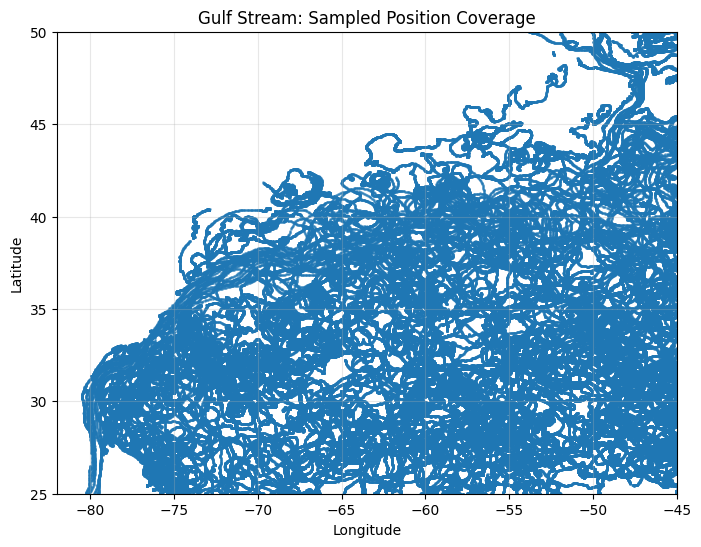

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    sample_lon,
    sample_lat,
    s=1,
    alpha=0.5
)

plt.xlim(west, east)
plt.ylim(south, north)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Gulf Stream: Sampled Position Coverage")

plt.grid(alpha=0.3)
plt.show()

In [11]:
lon_bins = np.arange(west, east + 1, 1)
lat_bins = np.arange(south, north + 1, 1)

grid_counts = np.zeros(
    (len(lat_bins) - 1, len(lon_bins) - 1),
    dtype=np.int64
)

chunk_size = 1_000_000
n = ds.sizes["obs"]

for start in range(0, n, chunk_size):
    end = min(start + chunk_size, n)

    lon_chunk = ds.lon.values[start:end]
    lat_chunk = ds.lat.values[start:end]

    mask = (
        (lon_chunk >= west) & (lon_chunk <= east) &
        (lat_chunk >= south) & (lat_chunk <= north)
    )

    counts, _, _ = np.histogram2d(
        lat_chunk[mask],
        lon_chunk[mask],
        bins=[lat_bins, lon_bins]
    )

    grid_counts += counts.astype(np.int64)

print("Total records in grid:", grid_counts.sum())

Total records in grid: 10373876


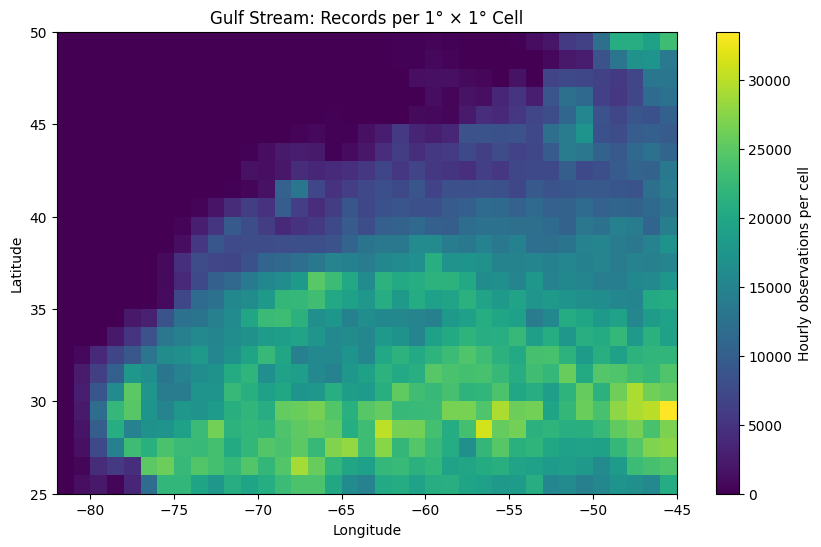

In [12]:
plt.figure(figsize=(10, 6))

plt.pcolormesh(
    lon_bins,
    lat_bins,
    grid_counts,
    shading="auto"
)

plt.colorbar(label="Hourly observations per cell")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Gulf Stream: Records per 1° × 1° Cell")

plt.xlim(west, east)
plt.ylim(south, north)

plt.show()

In [13]:
occupied = grid_counts[grid_counts > 0]

print("Occupied cells:", len(occupied))
print("Median records per occupied cell:", np.median(occupied))
print("10th percentile:", np.percentile(occupied, 10))
print("90th percentile:", np.percentile(occupied, 90))

Occupied cells: 724
Median records per occupied cell: 15431.5
10th percentile: 2229.5
90th percentile: 23693.4


右边的色条是Hourly observations per cell，颜色对应的数值越高，说明这个格子里的 GDP observations 越多，南部大约 25^\circ N-38^\circ N 数据非常丰富；往北之后数据逐渐减少。

Median = 15431.5说明：在 724 个有数据的 cells 中，一半的 cell 至少有大约 15,432 条 hourly observations，一半低于这个值。P10 = 2229.5，意味着即使在相对低数据量的 occupied cells 中，10th percentile 仍约有 2,230 observations。所以从 raw record availability 来说，这个候选区域的数据量是相当充足的。The color bar on the right is Hourly observations per cell. The higher the value corresponding to the color, the more GDP observations there are in this cell. The data in the south is approximately 25^\circ N-38^\circ N, which is very rich. The data gradually decreases after moving north.



Median = 15431.5 Note: Among the 724 cells with data, half of the cells had at least approximately 15,432 hourly observations, and half had less than this value. P10 = 2229.5, meaning that even in occupied cells with a relatively low data volume, the 10th percentile still has approximately 2,230 observations. So in terms of raw record availability, the data volume of this candidate region is quite sufficient.